In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import date
 
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
import category_encoders as ce
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


In [4]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)
 
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
 


In [5]:
# ── UČITAVANJE ────────────────────────────────────────────────────────────────
df = pd.read_sql("SELECT * FROM gold.unified_deduplicated", engine)
print(f"Učitano: {len(df)} oglasa")


Učitano: 23680 oglasa


In [6]:
df["datum_objave"] = pd.to_datetime(df["datum_objave"])
n_pre = len(df)
df = df[df["datum_objave"] >= "2025-01-01"].copy()
print(f"Odbačeno pre 2025: {n_pre - len(df)} | Ostalo: {len(df)}")
print(f"Raspon: {df['datum_objave'].min().date()} → {df['datum_objave'].max().date()}")

Odbačeno pre 2025: 3787 | Ostalo: 19893
Raspon: 2025-01-05 → 2026-05-04


In [32]:
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]
 
mask_sprat = (
    df["sprat"].notna() &
    df["ukupna_spratnost"].notna() &
    (df["ukupna_spratnost"] != 0)
)
df["sprat_ratio"] = np.where(
    mask_sprat,
    df["sprat"] / df["ukupna_spratnost"],
    np.nan
)
n_pre = len(df)
df = df[df["sprat_ratio"].isna() | df["sprat_ratio"].between(0, 1)].copy()
print(f"Odbačeno zbog sprat_ratio > 1: {n_pre - len(df)} oglasa")
 
bool_cols = ["uknjizen", "terasa", "interfon", "klima", "video_nadzor",
             "internet", "parking", "garaza", "lift", "podrum"]
df["amenity_score"] = df[bool_cols].sum(axis=1)
 
df["mesec"]       = df["datum_objave"].dt.month
df["kvartal"]     = df["datum_objave"].dt.quarter
df["godina"]    = df["datum_objave"].dt.year 
df["mesec_sin"]   = np.sin(2 * np.pi * df["mesec"] / 12)
df["mesec_cos"]   = np.cos(2 * np.pi * df["mesec"] / 12)
 
df["lokacija"] = df["lokacija"].replace("Nepoznato", None)
 

Odbačeno zbog sprat_ratio > 1: 0 oglasa


In [33]:
df = df.sort_values("datum_objave").reset_index(drop=True)
 
n       = len(df)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)
 
train = df.iloc[:n_train].copy()
val   = df.iloc[n_train : n_train + n_val].copy()
test  = df.iloc[n_train + n_val :].copy()
 
print(f"\nTrain: {len(train):>6} | do:  {train['datum_objave'].max().date()}")
print(f"Val:   {len(val):>6} | {val['datum_objave'].min().date()} → {val['datum_objave'].max().date()}")
print(f"Test:  {len(test):>6} | od:  {test['datum_objave'].min().date()}")
 


Train:  15876 | do:  2026-04-22
Val:     1984 | 2026-04-22 → 2026-04-27
Test:    1986 | od:  2026-04-27


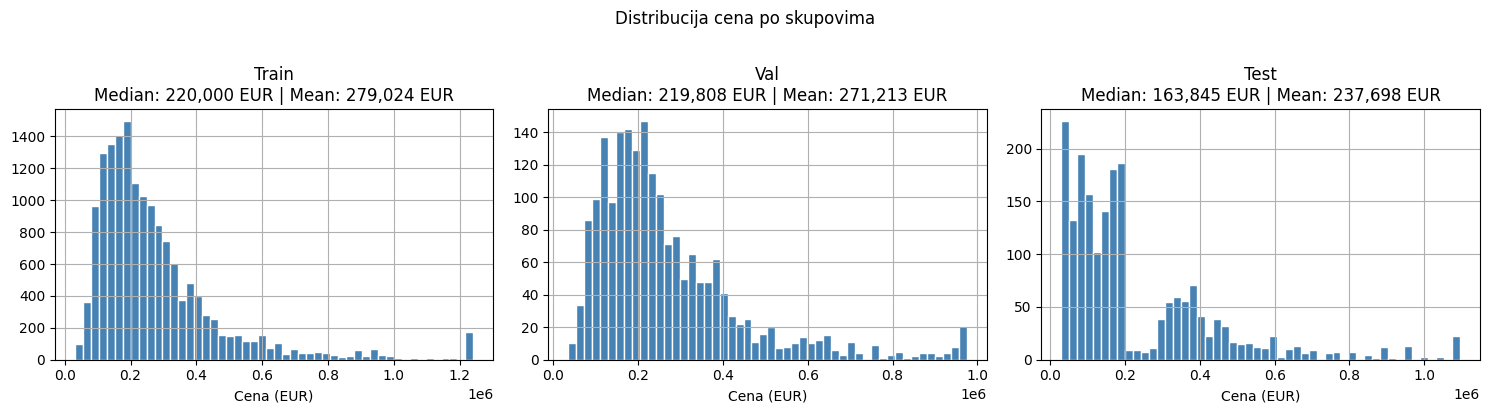

In [34]:
# Distribucija cena po skupovima — provjera distribution shifta
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, split) in zip(axes, [("Train", train), ("Val", val), ("Test", test)]):
    clip = split["price_total"].quantile(0.99)
    split["price_total"].clip(upper=clip).hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(
        f"{name}\nMedian: {split['price_total'].median():,.0f} EUR"
        f" | Mean: {split['price_total'].mean():,.0f} EUR"
    )
    ax.set_xlabel("Cena (EUR)")
plt.suptitle("Distribucija cena po skupovima", y=1.02)
plt.tight_layout()
plt.show()

In [35]:
encoder = ce.TargetEncoder(cols=["lokacija"])
train["lokacija_encoded"] = encoder.fit_transform(train["lokacija"], train["price_total"])
val["lokacija_encoded"]   = encoder.transform(val["lokacija"])
test["lokacija_encoded"]  = encoder.transform(test["lokacija"])

In [36]:
num_cols = [
    "kvadratura", "broj_soba", "sprat", "ukupna_spratnost",
    "sprat_ratio", "amenity_score",
    "mesec_sin", "mesec_cos", "kvartal", 'godina',  # ← umesto starost_oglasa
    "lokacija_encoded",
    "terasa", "parking", "garaza", "lift", "podrum",
    "internet", "klima", "interfon", "video_nadzor", "uknjizen",
]
cat_cols = ["stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine"]
 
feature_cols = num_cols + cat_cols
 
X_train = train[feature_cols].copy()
X_val   = val[feature_cols].copy()
X_test  = test[feature_cols].copy()
 
Y_train_raw = train["price_total"].values
Y_val_raw   = val["price_total"].values
Y_test_raw  = test["price_total"].values
 
# Log-transformacija targeta
# np.log1p(x) = log(x + 1) — bezbedno i za x=0
# Na kraju: np.expm1(y_pred) vraća originalne EUR vrednosti
Y_train = np.log1p(Y_train_raw)
Y_val   = np.log1p(Y_val_raw)
Y_test  = np.log1p(Y_test_raw)

In [37]:
num_imputer = SimpleImputer(strategy = 'median')
scaler = StandardScaler()

In [38]:
X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_val_num = scaler.transform(num_imputer.transform(X_val[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

In [39]:
cat_imputer = SimpleImputer(strategy = 'most_frequent')
ohe = OneHotEncoder(handle_unknown = 'ignore',sparse_output = False)

In [40]:
X_train_cat = ohe.fit_transform(cat_imputer.fit_transform(X_train[cat_cols]))
X_val_cat   = ohe.transform(cat_imputer.transform(X_val[cat_cols]))
X_test_cat  = ohe.transform(cat_imputer.transform(X_test[cat_cols]))

In [41]:
X_train_nn = np.hstack([X_train_num,X_train_cat])
X_val_nn   = np.hstack([X_val_num, X_val_cat])
X_test_nn  = np.hstack([X_test_num, X_test_cat])

In [42]:
print(f"Input shape: {X_train_nn.shape}")

Input shape: (15876, 98)


In [43]:
input_dim = X_train_nn.shape[1]

In [44]:
def evaluate(name, model, X, Y_raw):
    """
    Evaluira model. Predikcije su u log prostoru, pa ih invertujemo
    nazad u EUR pre računanja metrika.
    """
    y_pred_log = model.predict(X, verbose=0).flatten()
    y_pred_eur = np.expm1(y_pred_log)          # invertujemo log1p → EUR
    y_pred_eur = np.clip(y_pred_eur, 0, None)  # nema negativnih cena
 
    print(f"\n=== {name} ===")
    print(f"MAE:  {mean_absolute_error(Y_raw, y_pred_eur):,.0f} EUR")
    print(f"RMSE: {root_mean_squared_error(Y_raw, y_pred_eur):,.0f} EUR")
    print(f"R²:   {r2_score(Y_raw, y_pred_eur):.3f}")
    return y_pred_eur

In [45]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"],     label="Train MAE")
    plt.plot(history.history["val_loss"], label="Val MAE")
    plt.title(title)
    plt.xlabel("Epoha")
    plt.ylabel("MAE (EUR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [46]:
def get_callbacks(patience_es=20, patience_lr=12):
    return [
        EarlyStopping(patience=patience_es, restore_best_weights=True, monitor="val_loss"),
        ReduceLROnPlateau(factor=0.5, patience=patience_lr, monitor="val_loss"),
    ]
 


In [47]:
l2_strong = regularizers.l2(5e-4)
model_v1 = keras.Sequential([
    layers.Input(shape=(input_dim,)),
 
    layers.Dense(128, kernel_regularizer=l2_strong),
    layers.Activation("relu"),
    layers.Dropout(0.3),                           # jak dropout
 
    layers.Dense(64, kernel_regularizer=l2_strong),
    layers.Activation("relu"),
    layers.Dropout(0.3),
 
    layers.Dense(32, kernel_regularizer=l2_strong),
    layers.Activation("relu"),
    layers.Dropout(0.2),
 
    layers.Dense(1),
], name="v1_balanced")
 
model_v1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=keras.losses.Huber(delta=1.0),  # delta=1.0: standardna vrednost
)
 
history_v1 = model_v1.fit(
    X_train_nn, Y_train,
    validation_data=(X_val_nn, Y_val),
    epochs=300,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=0,
)


=== v1 (balanced) — VAL ===
MAE:  63,842 EUR
RMSE: 109,533 EUR
R²:   0.669

=== v1 (balanced) — TEST ===
MAE:  103,202 EUR
RMSE: 158,299 EUR
R²:   0.516


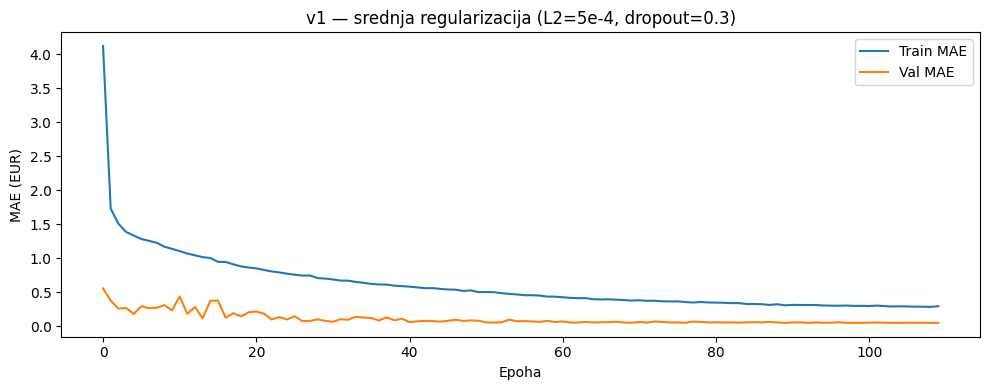

In [48]:
evaluate("v1 (balanced) — VAL",  model_v1, X_val_nn,  Y_val_raw)
evaluate("v1 (balanced) — TEST", model_v1, X_test_nn, Y_test_raw)
plot_history(history_v1, "v1 — srednja regularizacija (L2=5e-4, dropout=0.3)")

In [49]:
# MODEL v2 — Još plići model (64 → 32), maksimalni dropout

# ══════════════════════════════════════════════════════════════════════════════
l2_v2 = regularizers.l2(2e-3)

model_v2 = keras.Sequential([
    layers.Input(shape=(input_dim,)),
 
    layers.Dense(128, kernel_regularizer=l2_v2),
    layers.Activation("relu"),
    layers.Dropout(0.35),
 
    layers.Dense(64, kernel_regularizer=l2_v2),
    layers.Activation("relu"),
    layers.Dropout(0.35),
 
    layers.Dense(32, kernel_regularizer=l2_v2),
    layers.Activation("relu"),
    layers.Dropout(0.25),
 
    layers.Dense(1),
], name="v2_slightly_stronger")

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=keras.losses.Huber(delta=1.0),
)
 
history_v2 = model_v2.fit(
    X_train_nn, Y_train,
    validation_data=(X_val_nn, Y_val),
    epochs=300,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=0,
)


=== v2 (slightly stronger) — VAL ===
MAE:  74,112 EUR
RMSE: 127,843 EUR
R²:   0.549

=== v2 (slightly stronger) — TEST ===
MAE:  108,242 EUR
RMSE: 166,779 EUR
R²:   0.462


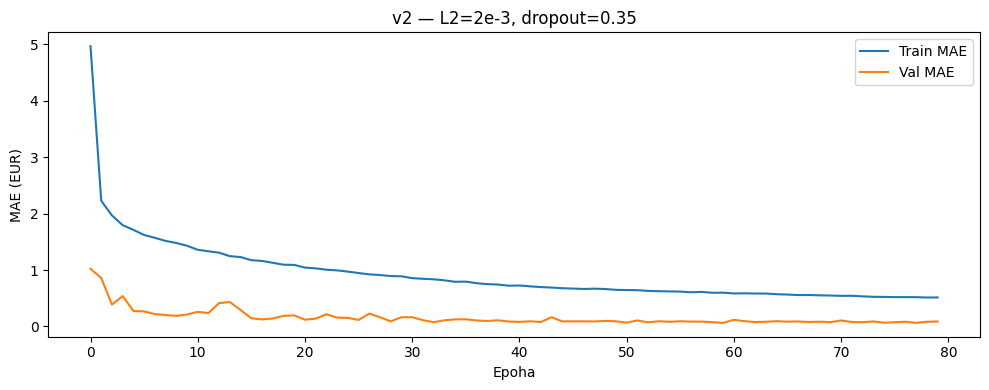

In [50]:
evaluate("v2 (slightly stronger) — VAL",  model_v2, X_val_nn,  Y_val_raw)
evaluate("v2 (slightly stronger) — TEST", model_v2, X_test_nn, Y_test_raw)
plot_history(history_v2, "v2 — L2=2e-3, dropout=0.35")
 

In [27]:
# MODEL v3 — Plića arhitektura (128 → 64 → 32), manji dropout
# ══════════════════════════════════════════════════════════════════════════════
model_v3 = keras.Sequential([
    layers.Input(shape=(input_dim,)),
 
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),
 
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),
 
    layers.Dense(32),
    layers.Activation("relu"),
 
    layers.Dense(1),
], name="v3_128_64_32")
 
model_v3.compile(optimizer=Adam(learning_rate=0.001), loss="mae")
 
history_v3 = model_v3.fit(
    X_train_nn, Y_train,
    validation_data=(X_val_nn, Y_val),
    epochs=300,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=0,
)


=== v3 — VAL ===
MAE:  52,564 EUR
RMSE: 89,201 EUR
R²:   0.768

=== v3 — TEST ===
MAE:  98,700 EUR
RMSE: 155,129 EUR
R²:   0.533


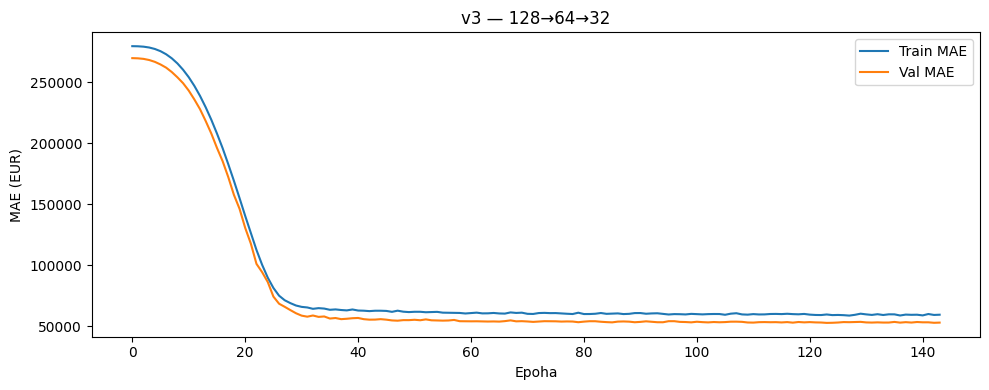

In [28]:
evaluate("v3 — VAL", model_v3, X_val_nn, Y_val)
evaluate("v3 — TEST", model_v3, X_test_nn, Y_test)
plot_history(history_v3, "v3 — 128→64→32")


In [51]:
# ── FINALNA TABELA ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("POREĐENJE — TEST SET")
print("=" * 60)
 
results = []
for name, (model, X, Y_raw) in {
    "v1 (no BN, strong reg)": (model_v1, X_test_nn, Y_test_raw),
    "v2 (minimal)":           (model_v2, X_test_nn, Y_test_raw),
}.items():
    y_pred = np.expm1(np.clip(model.predict(X, verbose=0).flatten(), 0, None))
    results.append({
        "Model": name,
        "MAE":   f"{mean_absolute_error(Y_test_raw, y_pred):,.0f} EUR",
        "RMSE":  f"{root_mean_squared_error(Y_test_raw, y_pred):,.0f} EUR",
        "R²":    f"{r2_score(Y_test_raw, y_pred):.3f}",
    })
 
print(pd.DataFrame(results).to_string(index=False))


POREĐENJE — TEST SET
                 Model         MAE        RMSE    R²
v1 (no BN, strong reg) 103,202 EUR 158,299 EUR 0.516
          v2 (minimal) 108,242 EUR 166,779 EUR 0.462
